# SC OT Visualizing Differences
To assess if the OT results make sense, we'll visualize a few comparisons to see if it all adds up.

## Imports

In [5]:
# Enabling fast reload
%load_ext autoreload
%autoreload 2

# Importing
import sys
import re
from pathlib import Path
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
sys.path.append('/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Scripts')
from hicdatautils import import_cool_dir, fetch_region, get_cool_name, bin_contact_map, hic_ot_source_to_targets
from hicvisutils import hic_vis_region

# Setting data directory
sc_dir = '/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Data/sc_data'
save_dir = '/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Generated Data/Single-to-single/sc_cell_type_clustering/ot'

# Saving metadata
metadata = pd.read_csv(sc_dir+"/cell_types.tsv", sep='\t')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Helper Functions

In [7]:
def map_cell_types(data: pd.DataFrame):
    '''
        Transforms fille name to file name comparisons in a pandas dataframe
        to a long format where each comparison has its own row, specifying inter
        or intra cell type of interest interactions.

        This function assusming formatting used in this notebook.

        Parameters
        ----------
        data : pd.DataFrame
            File name to file name dataframe of comparisons (SCC or OT).

        Returns
        -------
        data_long : pd.DataFrame
            A long format version of data with cell type information.
    '''

    # Mapping file to type
    type_lookup = metadata.set_index("cell_name")["cell_type"]

    # Long format
    data_long = data.reset_index().rename(columns={"index": "row_file"})
    data_long = data_long.melt(id_vars="row_file",
                        var_name="col_file",
                        value_name="value")
    # Mapping celltypes
    data_long["row_cell_type"] = data_long["row_file"].map(type_lookup)
    data_long["col_cell_type"] = data_long["col_file"].map(type_lookup)

    # Inter and intra
    data_long["relationship"] = (
        data_long["row_cell_type"] == data_long["col_cell_type"]
        ).map({True: "intra", False: "inter"})

    return data_long

def generate_ot_data(source_cell_type: str, res: int=8, thres: float=0, cell_count: int=20):
    '''
        Generates the OT data needed for the approach taken here

        This function is very specific to this notebook.

        Parameters
        ----------
        source_cell_type : str
            The cell type to be compared to all other cell types.
        res : int
            Resolution to bin the data to in Mb.
            Default = 8.
        thres : float
            Threshold to use for OT (percentile).
        cell_count : int
            The top number of cells to be used.
            Default = 20.

        Returns
        -------
        ot_results_long : pd.DataFrame
            Long format pandas dataframe with the desired results.
    '''
    ### Importing Data ###    
    # Metadata
    sampled_files = (
        metadata.groupby('cell_type')
                .apply(lambda x: x.sample(
                    n=min(len(x), cell_count),
                    replace=False,
                    random_state=42
                ))
                .reset_index(drop=True)
    )
    targets = list(sampled_files["cell_name"])
    sources = list(sampled_files[sampled_files["cell_type"] == source_cell_type]["cell_name"])

    # Coolers
    target_clrs = import_cool_dir(sc_dir, include=targets)
    source_clrs = import_cool_dir(sc_dir, include=sources)

    ### Performing OT ###
    # Saving directory
    ot_save_dir = '/Users/oliviersmeets/Desktop/University/Master Internship 1/Data Handling/Generated Data/Single-to-single/sc_cell_type_clustering/ot'

    # Prepping data
    target_chr1s = []
    target_names = []

    for clr in target_clrs:
        target_chr1s.append(fetch_region(clr, "chr1"))
        target_names.append(get_cool_name(clr))

    source_chr1s = []
    source_names = []

    for clr in source_clrs:
        source_chr1s.append(fetch_region(clr, "chr1"))
        source_names.append(get_cool_name(clr))

    # Binning
    target_chr1s_binned = []
    for chr1 in target_chr1s:
        target_chr1s_binned.append(bin_contact_map(chr1, res))

    source_chr1s_binned = []
    for chr1 in source_chr1s:
        source_chr1s_binned.append(bin_contact_map(chr1, res))

    # OT
    ot_results_list = []
    for map in source_chr1s_binned:
        ot_results_list.append(hic_ot_source_to_targets(map, target_chr1s_binned, thres, "percentile", "sum"))

    # Transform to dataframe
    ot_results_df = pd.DataFrame(ot_results_list, index=source_names, columns=target_names)

    # Saving
    ot_results_df.to_csv(f'{ot_save_dir}/{source_cell_type}_type_clustering_ot_{res}mb_{thres}_{cell_count}.csv')

    ### Transforming to long format ###
    ot_results_long = map_cell_types(ot_results_df)

    return ot_results_long

def ot_full_cell_type_comparison(res: int=8, thres: float=0, cell_count: int=20):
    '''
        Takes a resolution, threshold and cell count and performs
        OT between the top number of specified cells per cell type.
        Returns the data in a long format.

        This function is specific to this notebook.

        Parameters
        ----------
        res : int
            Resolution to bin the data to in Mb.
            Default = 8.
        thres : float
            Threshold to use for OT (percentile).
        cell_count : int
            The top number of cells to be used.
            Default = 20.
        
        Returns
        -------
        ot_compare_long : pd.DataFrame
            Long format dataframe
    '''
    # Loop through all cell types
    cell_types = metadata["cell_type"].unique()

        # Looping over cell types
    ot_long_dfs = []
    for ct in cell_types:
        ot_long_dfs.append(generate_ot_data(ct, res, thres, cell_count))
    
        # Concatenating 
    ot_compare_long = pd.concat(ot_long_dfs)

    return ot_compare_long

def generate_heatmap(long_df: pd.DataFrame, res: int, thres: float, cell_count: int):
    '''
        Takes long format dataframe generated from ot_full_cell_type_comparison()
        and generate a heatmap.

        This function is specifc to this notebook.

        Parameters
        ----------
        long_df : pd.DataFrame
            Long format dataframe to be visualized.
        res : int
            Resolution used for analysis. Used for figure title.
        thres : float
            Threshold used for analysis. Used for figure title.
        cell_count : int
            Top number of cells used for analysis. Used for figure
            title.
    '''
    # Calculating means
    ot_mean_matrix = long_df.groupby(
        ['row_cell_type', 'col_cell_type']
    )["value"].mean()

    # Showing heatmap
    ot_heatmap_df = ot_mean_matrix.unstack()
    plt.figure(figsize=(8, 6))
    sns.heatmap(ot_heatmap_df, annot=True, cmap='viridis', fmt=".0f")
    plt.title(f'Mean Chr1 OT Loss Across Cell-Type Pairs (Top {cell_count}, {res} Mb, {thres}%)')
    plt.show()
    return

def load_ot_results_long(folder: str, res: int, thres: int, cell_count: int):
    '''
        Loads all csv files corresponding to OT results
        in the given folder.

        This function is very specific to this notebook.

        Parameters
        ----------
        folder : str
            Path to folder that is to be imported.
        res : int
            Resolution used for analysis.
        thres : int
            Threshold used for analysis.
        cell_count : int
            Number of cells used for analysis.
        
        Returns
        -------
        ot_df_long : pd.Dataframe
            Long form dataframe with combined data from all
            OT results.
    '''
    folder = Path(folder)
    
    # Storage dictonary
    ot_dfs = []

    # Regex patterns
    cc = re.escape(str(cell_count))

    pattern = re.compile(
        rf"^(.*?)_type_clustering_ot_{res}mb_{thres}_{cell_count}\.csv$"
    )

    for file in folder.glob("*.csv"):
        name = file.name

        m = pattern.match(name)
        if m:
            df = pd.read_csv(file, index_col=0)
            ot_dfs.append(df)

    # Covert to long and concatenate
    metadata = pd.read_csv(sc_dir+"/cell_types.tsv", sep='\t')
    ot_dfs_long = []
    for df in ot_dfs:
        ot_dfs_long.append(map_cell_types(df))
    
    ot_df_long = pd.concat(ot_dfs_long)

    return ot_df_long

## Importing Data

### 1 Mb, 90% Threshold

In [8]:
long_1mb_90 = load_ot_results_long(save_dir, 1, 90, 20)

In [9]:
### Selecting Interesting Datapoints ###
    # Lowest OT cost (most similar)
long_1mb_90_nonzero = long_1mb_90[long_1mb_90["value"] != 0].reset_index(drop=True)
min_ot_1mb_90 = long_1mb_90_nonzero[long_1mb_90_nonzero["value"] == long_1mb_90_nonzero["value"].min()]
min_files = list(min_ot_1mb_90["row_file"])
min_value = min_ot_1mb_90["value"].unique()[0]

    # Highest OT cost (least similar)
max_ot_1mb_90 = long_1mb_90_nonzero[long_1mb_90_nonzero["value"] == long_1mb_90_nonzero["value"].max()]
max_files = list(max_ot_1mb_90["row_file"]) + list(max_ot_1mb_90["col_file"])
max_value = max_ot_1mb_90['value'].unique()[0]

    # Median OT cost
ot_1mb_90_median_value = long_1mb_90_nonzero["value"].median()
median_ot_1mb_90 = long_1mb_90_nonzero.loc[(long_1mb_90_nonzero["value"] - ot_1mb_90_median_value).abs().idxmin()]
median_files = [median_ot_1mb_90["row_file"], median_ot_1mb_90["col_file"]]
median_value = median_ot_1mb_90["value"]

In [10]:
### Importing Cools
min_1mb_90_clrs = import_cool_dir(sc_dir, include=min_files)
max_1mb_90_clrs = import_cool_dir(sc_dir, include=max_files)
median_1mb_90_clrs = import_cool_dir(sc_dir, include=median_files)

## Visualizing

### 1 Mb, 90% Threshold

Text(0.5, 0.98, 'Minimum OT Loss comparison (36.15)')

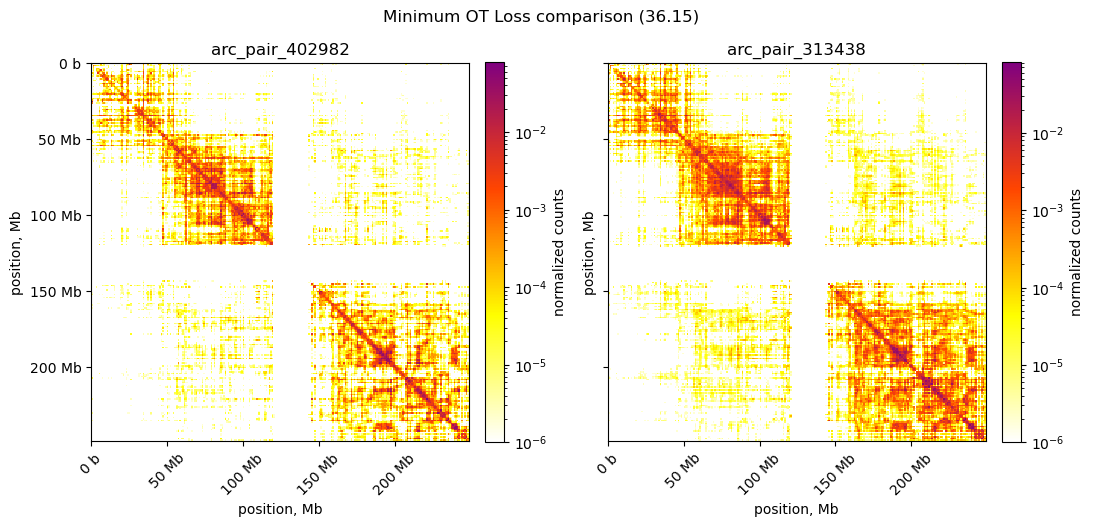

In [11]:
### Minimum OT cost ###
fig, axes = plt.subplots(1, 2, figsize=(12,5), sharex=True, sharey=True)
fig.subplots_adjust(wspace=0.25)
hic_vis_region(min_1mb_90_clrs[0], "chr1", data_type="normalized", ax=axes[0], cmap="higlass", title=get_cool_name(min_1mb_90_clrs[0]))
hic_vis_region(min_1mb_90_clrs[1], "chr1", data_type="normalized", ax=axes[1], cmap="higlass", title=get_cool_name(min_1mb_90_clrs[1]))
fig.suptitle(f"Minimum OT Loss comparison ({min_value:.2f})")

Text(0.5, 0.98, 'Maximum OT Loss comparison (12309.88)')

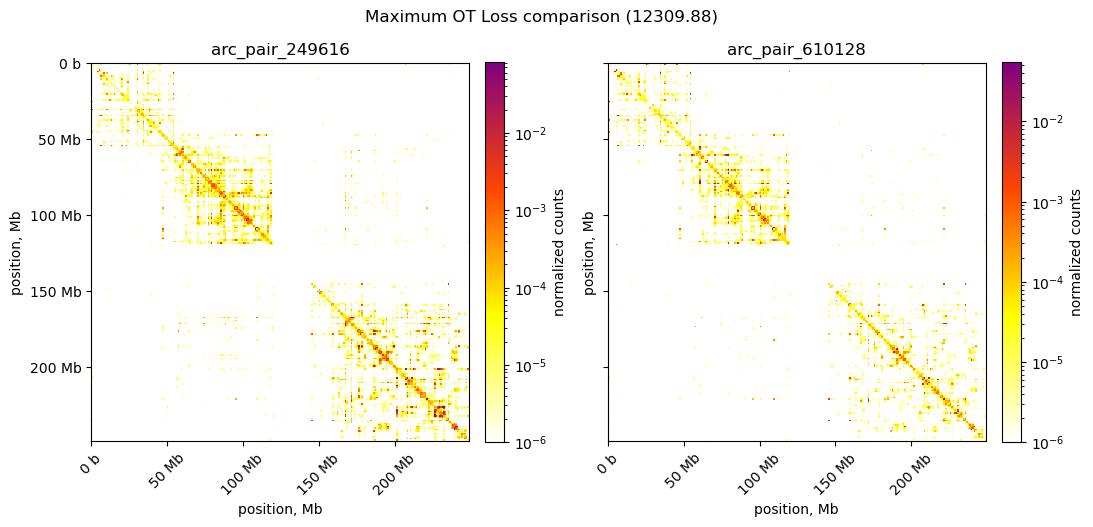

In [12]:
### Maximum OT cost ###
fig, axes = plt.subplots(1, 2, figsize=(12,5), sharex=True, sharey=True)
fig.subplots_adjust(wspace=0.25)
hic_vis_region(max_1mb_90_clrs[0], "chr1", data_type="normalized", ax=axes[0], cmap="higlass", title=get_cool_name(max_1mb_90_clrs[0]))
hic_vis_region(max_1mb_90_clrs[1], "chr1", data_type="normalized", ax=axes[1], cmap="higlass", title=get_cool_name(max_1mb_90_clrs[1]))
fig.suptitle(f"Maximum OT Loss comparison ({max_value:.2f})")

Text(0.5, 0.98, 'Median OT Loss comparison (1204.51)')

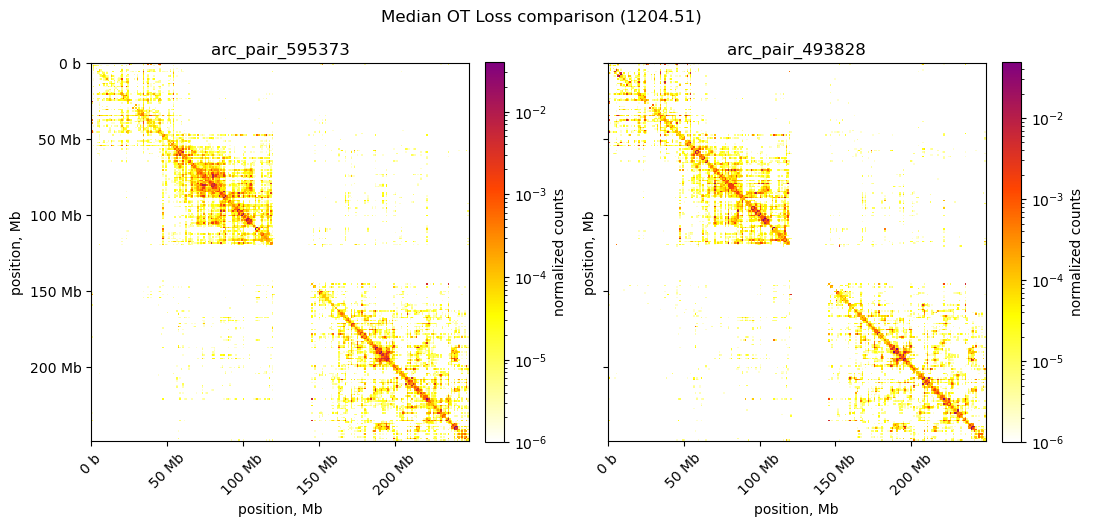

In [13]:
### Median OT cost ###
fig, axes = plt.subplots(1, 2, figsize=(12,5), sharex=True, sharey=True)
fig.subplots_adjust(wspace=0.25)
hic_vis_region(median_1mb_90_clrs[0], "chr1", data_type="normalized", ax=axes[0], cmap="higlass", title=get_cool_name(median_1mb_90_clrs[0]))
hic_vis_region(median_1mb_90_clrs[1], "chr1", data_type="normalized", ax=axes[1], cmap="higlass", title=get_cool_name(median_1mb_90_clrs[1]))
fig.suptitle(f"Median OT Loss comparison ({median_value:.2f})")